In [1]:
!pip install --quiet networkx matplotlib numpy

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import threading
import time
import networkx as nx


In [2]:
G = nx.Graph()

floors = 3
x_rooms = 4
y_rooms = 3

# Updated spacings
room_spacing_x = 24
room_spacing_y = 26
floor_spacing_z = 15  # vertical spacing between floors

room_ids = {}

for z in range(floors):
    for y in range(y_rooms):
        for x in range(x_rooms):
            room_num = z * 100 + 101 + (y * x_rooms + x)
            node_id = str(room_num)

            G.add_node(node_id,
                       type="room",
                       x=x * room_spacing_x,
                       y=y * room_spacing_y,
                       z=z * floor_spacing_z,  # this is the vertical separation
                       structural_integrity=1.0,
                       urgency=0.0,
                       gas_leak=False,
                       occupants=0,
                       trust_level=1.0)

            room_ids[(x, y, z)] = node_id

# ── DESIGNATE GAS MAIN IN A ROOM ──
# (for this example, put it in Room 101 at (0,0,0))
gas_room = room_ids[(0, 1, 0)]
G.nodes[gas_room]['has_gas_main'] = True
print(f"🔍 Gas main located at room {gas_room}")


🔍 Gas main located at room 105


In [3]:
# Connect horizontal (E/W) rooms in each row
for z in range(floors):
    for y in range(y_rooms):
        for x in range(x_rooms - 1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x + 1, y, z)]
            G.add_edge(n1, n2,
                       edge_type="hallway",
                       status="open",
                       distance=room_spacing_x,
                       trust_score=1.0,
                       structural_risk=0.0,
                       hazard_level='healthy')
            if random.random() < 0.15:
                G[n1][n2]['hazard_level'] = 'caution'


# Connect vertical (N/S) outer columns only: left column (x=0), right column (x=3)
outer_cols = [0, x_rooms - 1]

for z in range(floors):
    for x in outer_cols:
        for y in range(y_rooms - 1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x, y + 1, z)]
            G.add_edge(n1, n2,
                       edge_type="hallway",
                       status="open",
                       distance=room_spacing_y,
                       trust_score=1.0,
                       structural_risk=0.0,
                       hazard_level='healthy')
            if random.random() < 0.15:
                G[n1][n2]['hazard_level'] = 'caution'



In [4]:
floor_height = floor_spacing_z  # use the spacing that matches your Z coordinate

# Elevator in front-left corner (x=0, y=0)
elevator_stack = [(0, 0)]

# Stairs ONLY in back right corner
stair_stack = [(3,2)]

# Elevator edges
for x, y in elevator_stack:
    for z in range(floors - 1):
        if (x, y, z) in room_ids and (x, y, z + 1) in room_ids:
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x, y, z + 1)]
            G.add_edge(n1, n2,
                       edge_type="elevator",
                       status="open",
                       distance=floor_height,
                       trust_score=1.0,
                       structural_risk=0.0,
                       hazard_level='healthy')


# Add stair connections only at (0, 2)
for x, y in stair_stack:
    for z in range(floors - 1):
        n1 = room_ids.get((x, y, z))
        n2 = room_ids.get((x, y, z + 1))
        if n1 and n2:
            G.add_edge(n1, n2,
                       edge_type="stair",
                       status="open",
                       distance=floor_spacing_z,
                       trust_score=1.0,
                       structural_risk=0.0,
                       hazard_level='healthy')
            print(f"Stair edge between {n1} and {n2}")




Stair edge between 112 and 212
Stair edge between 212 and 312


In [5]:
# Check if the graph is fully connected
if nx.is_connected(G):
    print("✅ The hospital graph is fully connected.")
else:
    print("❌ The graph is NOT connected. There may be isolated rooms or missing edges.")


✅ The hospital graph is fully connected.


In [6]:
room_types = ["ward", "ICU", "OR", "storage", "lobby"]
for node, data in G.nodes(data=True):
    if data.get("type") == "room":
        G.nodes[node].update({
            "room_type": random.choice(room_types),
            "structural_integrity": 1.0,
            "temperature": 22.0,
            "gas_leak": False,
            "urgency": 0.0,
            "lighting": 1.0,
            "occupants": random.randint(0, 3)
        })


In [7]:
# 🚪 Add Exit Node between Room 102 and 103 (on floor 0)
room_102 = room_ids[(1, 0, 0)]  # This gives you "102"
room_103 = room_ids[(2, 0, 0)]  # This gives you "103"

# Get positions of each room
x1, y1, z1 = G.nodes[room_102]["x"], G.nodes[room_102]["y"], G.nodes[room_102]["z"]
x2, y2, z2 = G.nodes[room_103]["x"], G.nodes[room_103]["y"], G.nodes[room_103]["z"]

# Midpoint position
exit_x = (x1 + x2) / 2
exit_y = (y1 + y2) / 2
exit_z = z1  # same floor

# Create EXIT node
exit_node_id = "EXIT"
G.add_node(exit_node_id,
           type="exit",
           x=exit_x,
           y=exit_y,
           z=exit_z)

# Connect to both rooms
G.add_edge(room_102, exit_node_id,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)

G.add_edge(room_103, exit_node_id,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)

print(f"✅ Exit node placed between {room_102} and {room_103}")


✅ Exit node placed between 102 and 103


In [8]:

for (x, y, z), room_id in room_ids.items():
    if x == x_rooms - 1:  # east-most column
        G.nodes[room_id]["structural_integrity"] = round(random.uniform(0.1, 0.4), 2)
        #G.nodes[room_id]["gas_leak"] = random.random() < 0.5
        G.nodes[room_id]["lighting"] = round(random.uniform(0.0, 0.3), 2)
        G.nodes[room_id]["urgency"] = round(random.uniform(0.7, 1.0), 2)


In [9]:
# EAST-MOST COLUMN: status + hazard_level + other attributes
for (x, y, z), room_id in room_ids.items():
    if x == x_rooms - 1:  # east-most column
        for nbr in G.neighbors(room_id):
            edge = G[room_id][nbr]
            # set status and matching hazard_level
            status = "blocked" if random.random() < 0.5 else "open"
            edge["status"] = status
            edge["hazard_level"] = "blocked" if status == "blocked" else "healthy"
            # other randomly degraded attributes
            edge["structural_risk"] = round(random.uniform(0.4, 1.0), 2)
            edge["trust_score"] = round(random.uniform(0.1, 0.5), 2)
            edge["visibility"] = round(random.uniform(0.0, 0.3), 2)


In [10]:
# ── ENSURE EVERY EDGE HAS hazard_level ──
for u, v, attr in G.edges(data=True):
    if attr.get('status') == 'blocked':
        G[u][v]['hazard_level'] = 'blocked'
    elif 'hazard_level' not in attr:
        G[u][v]['hazard_level'] = 'healthy'


In [11]:
def assign_minor_hazards(G, x_range=None, z_range=None):
    """
    Randomly add minor hazard attributes to rooms.
    - x_range: tuple of x positions to target (e.g. (2, 4)), or None for all
    - z_range: tuple of z (floor) values to target (e.g. (0, 2)), or None for all
    """
    hazard_types = ["glass_shards", "obstruction", "slippery", "ceiling_damage"]
    affected = 0

    for n, d in G.nodes(data=True):
        if d.get("type") != "room":
            continue

        x = int(d["x"] // room_spacing_x)
        z = d["z"]

        if x_range and not (x_range[0] <= x <= x_range[1]):
            continue
        if z_range and not (z_range[0] <= z <= z_range[1]):
            continue

        for hazard in hazard_types:
            d[hazard] = random.random() < 0.1

        if any(d.get(h) for h in hazard_types):
            affected += 1

    print(f"✔️ Minor hazards assigned to {affected} rooms.")




In [12]:
assign_minor_hazards(G)



✔️ Minor hazards assigned to 15 rooms.


In [13]:
# Check how many rooms actually got hazards (Debug)
hazard_types = ["glass_shards", "obstruction", "slippery", "ceiling_damage"]
hazard_count = 0

for n, d in G.nodes(data=True):
    if d.get("type") != "room":
        continue
    if any(d.get(h, False) for h in hazard_types):
        print(f"⚠️ Room {n} has hazards: {[h for h in hazard_types if d.get(h, False)]}")
        hazard_count += 1

if hazard_count == 0:
    print("❌ No hazards assigned. Something is wrong.")
else:
    print(f"✅ {hazard_count} rooms have at least one hazard.")


⚠️ Room 103 has hazards: ['glass_shards']
⚠️ Room 106 has hazards: ['ceiling_damage']
⚠️ Room 108 has hazards: ['obstruction']
⚠️ Room 109 has hazards: ['glass_shards']
⚠️ Room 111 has hazards: ['glass_shards']
⚠️ Room 201 has hazards: ['glass_shards']
⚠️ Room 202 has hazards: ['obstruction']
⚠️ Room 203 has hazards: ['glass_shards']
⚠️ Room 206 has hazards: ['glass_shards']
⚠️ Room 208 has hazards: ['slippery']
⚠️ Room 301 has hazards: ['obstruction']
⚠️ Room 302 has hazards: ['ceiling_damage']
⚠️ Room 306 has hazards: ['ceiling_damage']
⚠️ Room 309 has hazards: ['slippery']
⚠️ Room 311 has hazards: ['glass_shards', 'slippery']
✅ 15 rooms have at least one hazard.


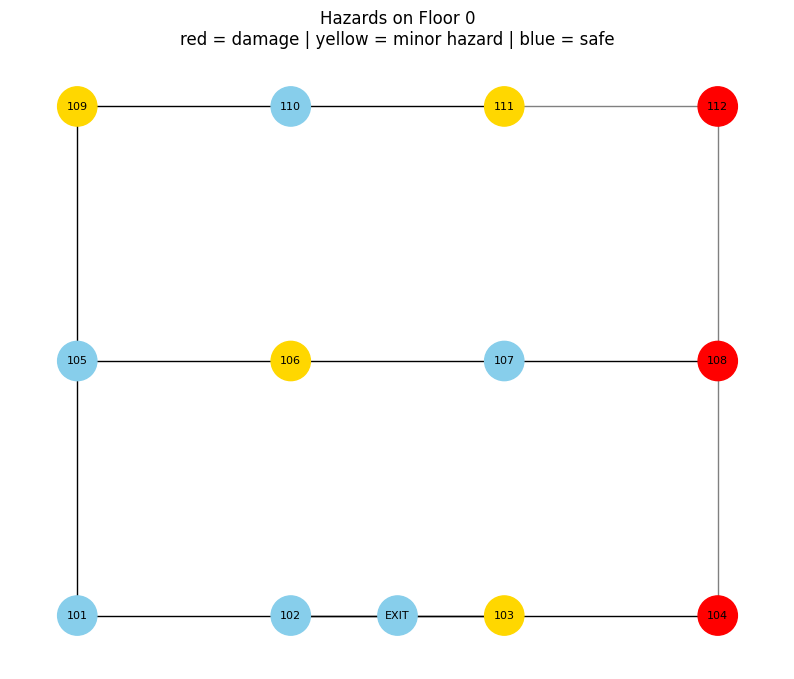

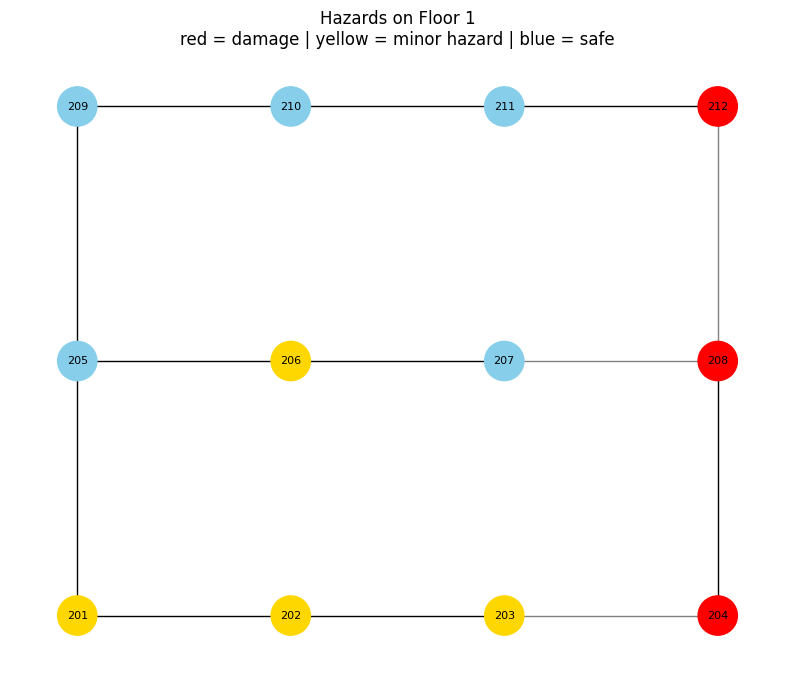

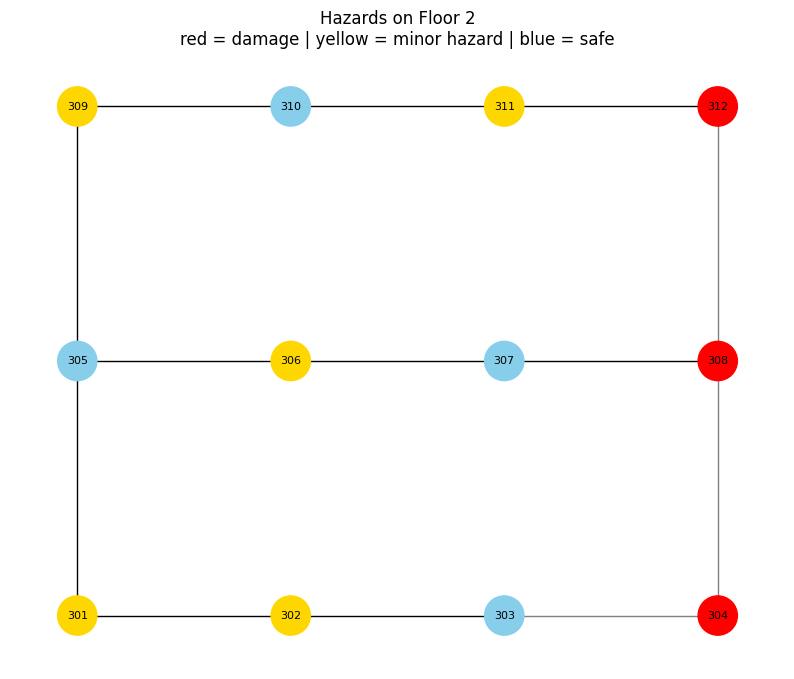

In [14]:
def visualize_hazards_on_floor(G, z_level):
    plt.figure(figsize=(10, 8))

    # Get nodes on this floor
    floor_nodes = [n for n, d in G.nodes(data=True) if d["z"] == z_level * floor_spacing_z]
    pos = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in floor_nodes}

    # Determine node color
    node_colors = []
    for n in floor_nodes:
        d = G.nodes[n]
        integrity = d.get("structural_integrity", 1.0)
        has_minor_hazard = any([
            d.get("glass_shards", False),
            d.get("obstruction", False),
            d.get("slippery", False),
            d.get("ceiling_damage", False)
        ])

        if integrity < 0.5:
            node_colors.append("red")      # major structural damage
        elif has_minor_hazard:
            node_colors.append("gold")     # minor hazard only
        else:
            node_colors.append("skyblue")  # safe room



    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=floor_nodes, node_color=node_colors, node_size=800)
    nx.draw_networkx_labels(G, pos, labels={n: n for n in floor_nodes}, font_size=8)

    # Draw edges
    floor_edges = [(u, v) for u, v in G.edges() if u in floor_nodes and v in floor_nodes]
    edge_colors = ["gray" if G[u][v].get("status") == "blocked" else "black" for u, v in floor_edges]
    nx.draw_networkx_edges(G, pos, edgelist=floor_edges, edge_color=edge_colors)

    plt.title(f"Hazards on Floor {z_level}\nred = damage | yellow = minor hazard | blue = safe")
    plt.axis("off")
    plt.show()

for z in range(floors):
    visualize_hazards_on_floor(G, z)


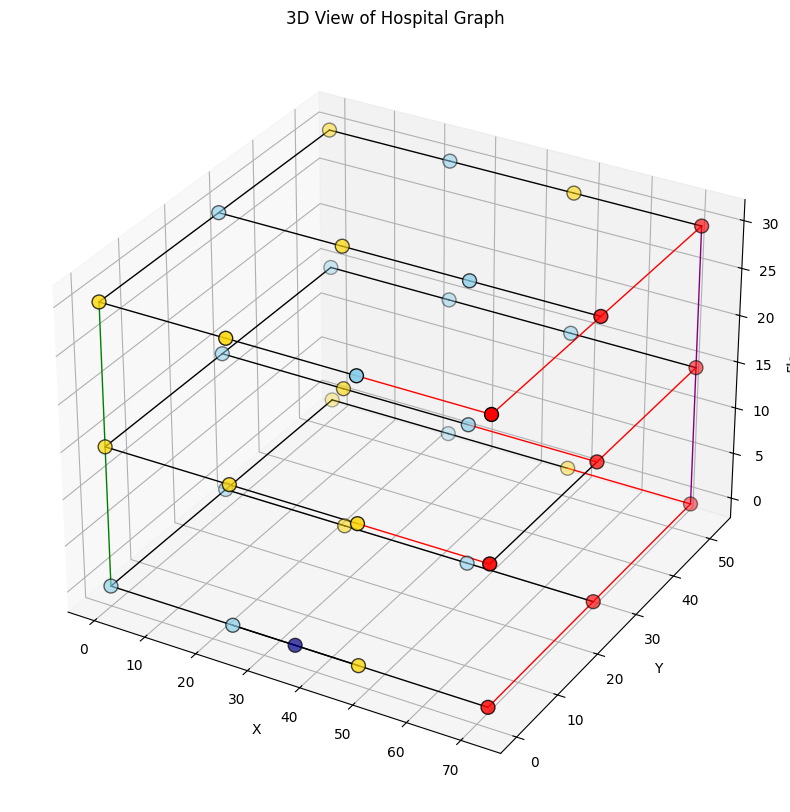

In [15]:
from mpl_toolkits.mplot3d import Axes3D

def visualize_hospital_3D(G):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Position of each node
    node_pos = {}
    xs, ys, zs, colors = [], [], [], []

    for n, d in G.nodes(data=True):
        if d.get("type") not in ["room", "exit"]:
            continue
        x, y, z = d["x"], d["y"], d["z"]
        node_pos[n] = (x, y, z)
        xs.append(x)
        ys.append(y)
        zs.append(z)

        # Color nodes
        if d.get("type") == "exit":
            colors.append("darkblue")  # Exit node color
        else:
            integrity = d.get("structural_integrity", 1.0)
            has_minor_hazard = any([
                d.get("glass_shards", False),
                d.get("obstruction", False),
                d.get("slippery", False),
                d.get("ceiling_damage", False)
            ])

            if integrity < 0.5:
                colors.append("red")
            elif has_minor_hazard:
                colors.append("gold")
            else:
                colors.append("skyblue")

    # Draw nodes
    ax.scatter(xs, ys, zs, c=colors, s=100, edgecolors='k')

    # Draw edges
    for u, v, attr in G.edges(data=True):
        if u not in node_pos or v not in node_pos:
            continue
        x_vals = [node_pos[u][0], node_pos[v][0]]
        y_vals = [node_pos[u][1], node_pos[v][1]]
        z_vals = [node_pos[u][2], node_pos[v][2]]

        # Color edges based on priority
        if attr.get("edge_type") == "stair":
            color = "purple"
        elif attr.get("edge_type") == "elevator":
            color = "green"
        elif attr.get("hazard") == "debris":
            color = "yellow"
        elif attr.get("status") == "blocked":
            color = "red"
        else:
            color = "black"


        ax.plot(x_vals, y_vals, z_vals, color=color, linewidth=1)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Floor")
    ax.set_title("3D View of Hospital Graph")
    plt.show()

# Run it
visualize_hospital_3D(G)


In [16]:
# ── MARK ROOMS WITH ALL-EDGE BLOCKAGES ──
blocked_rooms = {
    n
    for n,d in G.nodes(data=True)
    if d.get("type")=="room"
    and all(
        G[n][nbr]["hazard_level"] == "blocked"
        for nbr in G.neighbors(n)
    )
}
print(f"🚧 Blocked rooms (no open corridors): {sorted(blocked_rooms)}")


🚧 Blocked rooms (no open corridors): ['112', '304']


In [17]:
# ── LOCAL KNOWLEDGE SHARING SETUP ──

import networkx as nx
import threading

# 1) Shared map: what rooms have been seen and where patients are
shared_map = {
    'discovered_nodes': set(),   # rooms we've “seen” so far
    'patients': {}               # mapping room_id → occupancy
}
map_lock = threading.Lock()

# 2) Local navigator: shortest path on the subgraph of discovered nodes
# ── LOCAL ROUTER WITH BLOCKED‐EDGE FILTERING ──




In [18]:
# ── SEED A GAS LEAK ──
# (Change the tuple if you want a different room)
leak_room = room_ids[(0, 0, 0)]
G.nodes[leak_room]['gas_leak'] = True
print(f"🔍 Gas leak seeded in room {leak_room}")


🔍 Gas leak seeded in room 101


In [19]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def visualize_path_3D(G, path):
    """
    Draw the full hospital graph in light gray/blue,
    then overlay the agent's path in bold red.
    """
    # Build 3D positions for rooms and exit
    node_pos = {
        n: (d['x'], d['y'], d['z'])
        for n, d in G.nodes(data=True)
        if d.get("type") in ("room", "exit")
    }

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1) Draw all edges in light gray
    for u, v in G.edges():
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='lightgray', linewidth=1)

    # 2) Draw all nodes (rooms in skyblue, exit in darkblue)
    for n, (x, y, z) in node_pos.items():
        color = 'darkblue' if G.nodes[n]['type'] == 'exit' else 'skyblue'
        ax.scatter(x, y, z, c=color, s=50, edgecolors='k', alpha=0.6)

    # 3) Overlay the path edges in red
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='red', linewidth=3)

    # 4) Highlight the path nodes in red
    for n in path:
        if n in node_pos:
            x, y, z = node_pos[n]
            ax.scatter(x, y, z, c='red', s=100, edgecolors='k')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (floor)")
    ax.set_title("3D Hospital Graph with Agent Path (red)")
    plt.show()


In [20]:
import random

# ── EXPLORER THAT RETURNS THE FULL SEQUENCE ──
def explore_with_sequence(G, start):
    visited = {start}
    stack   = [start]
    sequence = []

    while stack:
        current = stack[-1]
        sequence.append(current)

        # 1) sniff current room
        if G.nodes[current].get('gas_leak', False):
            return sequence, stack

        # 2) sense hazards (for record only)
        for nbr in G.neighbors(current):
            _ = G[current][nbr].get('hazard_level', 'healthy')

        # 3) pick a random, unvisited, unblocked neighbor
        nbrs = [
            nbr for nbr in G.neighbors(current)
            if nbr not in visited
            and G[current][nbr].get('hazard_level','healthy')!='blocked'
            and nbr not in blocked_rooms            # <- skip fully blocked rooms
        ]

        random.shuffle(nbrs)

        if nbrs:
            nxt = nbrs[0]
            visited.add(nxt)
            stack.append(nxt)
        else:
            stack.pop()

    return sequence, None

# ── 3D VISUALIZER FOR THE EXPLORATION SEQUENCE ──
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def visualize_exploration_3D(G, sequence):
    node_pos = {
        n: (d['x'], d['y'], d['z'])
        for n, d in G.nodes(data=True)
        if d.get("type") in ("room","exit")
    }

    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111, projection='3d')

    # faint hospital graph
    for u, v in G.edges():
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='lightgray', linewidth=1)

    # rooms & exit
    for n,(x,y,z) in node_pos.items():
        color = 'darkblue' if G.nodes[n]['type']=='exit' else 'skyblue'
        ax.scatter(x,y,z, c=color, s=50, edgecolors='k', alpha=0.6)

    # exploration in orange
    for i in range(len(sequence)-1):
        u, v = sequence[i], sequence[i+1]
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='orange', linewidth=2)

    # step‐number labels
    for idx, n in enumerate(sequence):
        if n in node_pos:
            x,y,z = node_pos[n]
            ax.text(x, y, z, str(idx), color='red', fontsize=8, zorder=10)
            ax.scatter(x, y, z, c='red', s=80, edgecolors='k')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (floor)")
    ax.set_title("3D Exploration Sequence (orange) with Step Numbers")
    plt.show()


🔎 Full exploration sequence: 303 → 302 → 301 → 305 → 309 → 310 → 311 → 312 → 212 → 211 → 210 → 209 → 205 → 206 → 207 → 206 → 205 → 201 → 202 → 203 → 202 → 201 → 101
🛣️ Leak found! Final path: 303 → 302 → 301 → 305 → 309 → 310 → 311 → 312 → 212 → 211 → 210 → 209 → 205 → 201 → 101


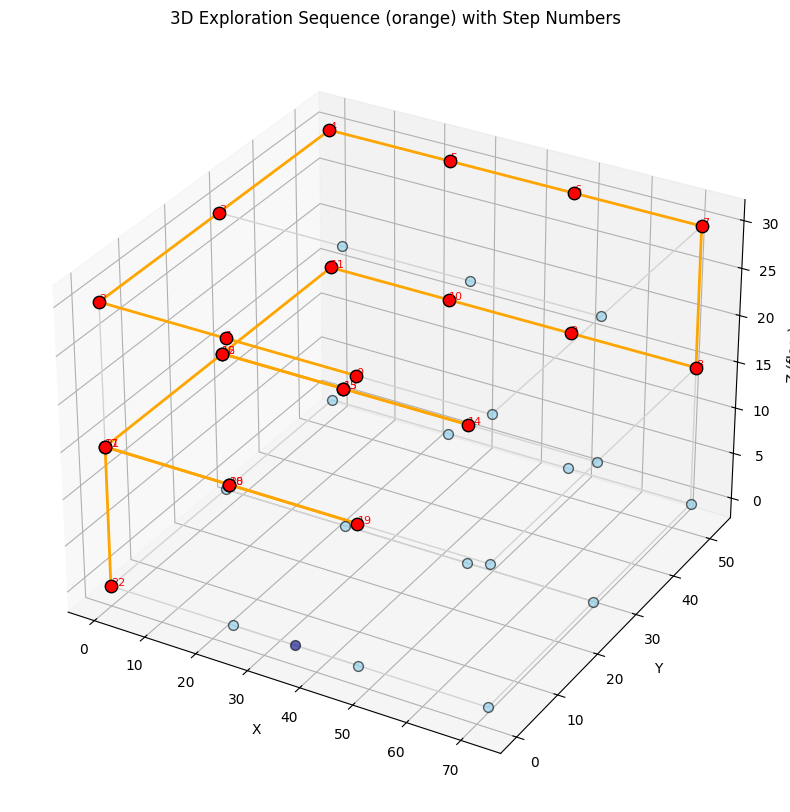

In [21]:
# ── RUN & VISUALIZE FULL EXPLORATION ──
start_room = room_ids[(2, 0, 2)]  # "303"
sequence, path = explore_with_sequence(G, start_room)

print("🔎 Full exploration sequence:", " → ".join(sequence))
if path:
    print("🛣️ Leak found! Final path:", " → ".join(path))
else:
    print("❌ Leak not found from", start_room)

visualize_exploration_3D(G, sequence)


In [22]:
#trying second interesting scenarion where we check for patients
def explore_for_patients(G, start):
    """
    DFS + backtracking sensor bot that records any room with occupants>0.
    Returns the exploration sequence and a dict mapping room_id→occupants.
    """
    visited = {start}
    stack   = [start]
    sequence = []
    found    = {}

    while stack:
        current = stack[-1]
        sequence.append(current)

        # record occupants if any
        occ = G.nodes[current].get('occupants', 0)
        if occ > 0:
            found[current] = occ

        # sense hazards (but don’t use for sensor)
        for nbr in G.neighbors(current):
            _ = G[current][nbr].get('hazard_level','healthy')

        # pick next unvisited, unblocked neighbor
        nbrs = [
            nbr for nbr in G.neighbors(current)
            if nbr not in visited
            and G[current][nbr].get('hazard_level','healthy')!='blocked'
            and nbr not in blocked_rooms            # <- skip fully blocked rooms
        ]

        nbrs.sort(key=lambda n: random.random())  # shuffle
        if nbrs:
            nxt = nbrs[0]
            visited.add(nxt)
            stack.append(nxt)
        else:
            stack.pop()

    return sequence, found


In [23]:
def navigate_and_return(G, start, target, speed=0.8):
    """
    Greedy, local‐knowledge evacuation bot:
      1) navigate from `start` to `target`,
      2) then back to `start`.
    Returns two lists: path_out, path_back.
    """
    def navigate(G, start, goal):
        visited = {start}
        path = [start]
        while path[-1] != goal:
            cur = path[-1]
            nbrs = []
            for nbr in G.neighbors(cur):
                lvl = G[cur][nbr].get('hazard_level','healthy')
                # skip blocked edges, visited rooms, or fully-blocked rooms
                if lvl=='blocked' or nbr in visited or nbr in blocked_rooms:
                    continue

                # heuristic = euclid to goal + travel penalty
                x1,y1 = G.nodes[nbr]['x'], G.nodes[nbr]['y']
                x2,y2 = G.nodes[goal]['x'],G.nodes[goal]['y']
                dist_est = ((x1-x2)**2 + (y1-y2)**2)**0.5
                score = dist_est + traversal_time(cur, nbr, speed)
                nbrs.append((score, nbr))

            if not nbrs:
                path.pop()
                if not path:
                    return None
                continue

            nxt = min(nbrs, key=lambda x: x[0])[1]
            visited.add(nxt)
            path.append(nxt)
        return path

    path_out  = navigate(G, start, target)
    path_back = navigate(G, target, start) if path_out else None
    return path_out, path_back


In [24]:
# ── SUM UP REAL TRAVERSAL TIMES AT 4 FT/S ──
def path_travel_time(G, path, speed=4.0):
    total = 0.0
    for u, v in zip(path, path[1:]):
        total += traversal_time(u, v, speed)
    return total

# ── LOCAL‐KNOWLEDGE SENSOR+ROBOT DRIVER ──

import threading

# ─── RESET shared_map BEFORE EACH EXPERIMENT ───
shared_map = {
    'discovered_nodes': set(),
    'patients': {}
}
map_lock   = threading.Lock()

rescue_log     = []
coverage_rooms = set()
lock           = threading.Lock()

sensor_starts = [
    room_ids[(0, 0, 0)],  # Room 101
    room_ids[(1, 1, 1)],  # Room 206
    room_ids[(2, 1, 2)]   # Room 307
]
print("🔧 Active sensors:", sensor_starts)

# ── LOCAL ROUTER WITH DEBUG ─




🔧 Active sensors: ['101', '206', '307']


In [25]:
# ── LOCAL VS GLOBAL COMPARISON SETUP ──
import threading, time, math

# snapshot initial patient counts
initial_room_occ = {
    n: d['occupants']
    for n, d in G.nodes(data=True)
    if d.get('type') == 'room' and d['occupants'] > 0
}

# ── SANITY CHECK: list patients per room & total ──
print("🔍 Sanity check: initial patient distribution")
total_patients = 0
for room, occ in sorted(initial_room_occ.items()):
    print(f"Room {room}: {occ} patient{'s' if occ>1 else ''}")
    total_patients += occ
print(f"🏥 Total patients across all rooms: {total_patients}")
print("────────────────────────────────────────────")


# shared state for local threaded dispatch
map_lock            = threading.Lock()
cleared_rooms       = set()
rooms_with_patients = set(initial_room_occ)
local_rescue_log    = []
coverage_rooms      = set()

# ── HELPERS ──
def traversal_time(u, v, speed=4.0):
    e = G[u][v]
    if e.get('hazard_level','healthy') == 'blocked':
        return float('inf')
    penalty = 1.0 if e['hazard_level']=='healthy' else 1.5
    return (e['distance']/speed)*penalty

def navigate_local(start, goal, speed=4.0):
    """
    Greedy local navigator: falls back to a true shortest-path
    on the subgraph without blocked edges.
    """
    # Build a subgraph excluding blocked corridors
    H = G.copy()
    for u, v, attr in list(H.edges(data=True)):
        if attr.get('hazard_level') == 'blocked':
            H.remove_edge(u, v)

    try:
        # weight is pure distance / speed
        return nx.shortest_path(
            H, start, goal,
            weight=lambda u, v, d: d['distance'] / speed
        )
    except nx.NetworkXNoPath:
        return None


def choose_best_target(current_pos, speed=4.0):
    best, best_cost = None, float('inf')
    for r in rooms_with_patients - cleared_rooms:
        p = navigate_local(current_pos, r, speed)
        if not p:
            continue
        c = sum(traversal_time(u,v,speed) for u,v in zip(p,p[1:]))
        if c < best_cost:
            best_cost, best = c, r
    return best

# ── SUM UP REAL TRAVERSAL TIMES AT 4 FT/S ──
def path_travel_time(G, path, speed=4.0):
    total = 0.0
    for u, v in zip(path, path[1:]):
        total += traversal_time(u, v, speed)
    return total

# ── LOCAL‐KNOWLEDGE SENSOR+ROBOT DRIVER (deduped) ──
import threading

rescue_log     = []
coverage_rooms = set()
lock           = threading.Lock()

sensor_starts = [
    room_ids[(0, 0, 0)],  # Room 101
    room_ids[(1, 1, 1)],  # Room 206
    room_ids[(2, 1, 2)]   # Room 307
]
print("🔧 Active sensors:", sensor_starts)

def sensor_worker(start):
    # 1) Explore & collect local findings
    seq, found = explore_for_patients(G, start)

    # 2) Publish those findings to shared_map
    with map_lock:
        shared_map['discovered_nodes'].update(seq)
        for room_id, occ in found.items():
            if room_id not in shared_map['patients']:
                shared_map['patients'][room_id] = occ

    # 3) Log header & coverage
    log = [
        f"🔎 Sensor @ {start} explored: {' → '.join(seq)}",
        f"👥 Shared patient map now: {shared_map['patients']}"
    ]
    with lock:
        coverage_rooms.update(n for n in seq if G.nodes[n]['type']=='room')

    # 4) Dispatch robots—but only for rooms still in shared_map
    for room_id in list(found):
        with map_lock:
            occ = shared_map['patients'].pop(room_id, 0)
        if occ == 0:
            log.append(f"⚠️ Skipping {room_id}, already cleared")
            continue

        path = navigate_local(exit_node_id, room_id, speed=4.0)
        if path:
            t_out   = path_travel_time(G, path,  speed=4.0)
            t_back  = path_travel_time(G, list(reversed(path)), speed=4.0)
            t_total = t_out + t_back

            # zero out the room so no other sensor thinks there are still patients
            G.nodes[room_id]['occupants'] = 0

            rescue_log.append({
                'sensor': start, 'room': room_id,
                'patients': occ, 'time': t_total
            })
            log.append(
                f"🚑 Rescued {occ} from {room_id} "
                f"(out {t_out:.2f}s + back {t_back:.2f}s = {t_total:.2f}s)"
            )
        else:
            rescue_log.append({
                'sensor': start, 'room': room_id,
                'patients': occ, 'time': float('inf')
            })
            log.append(f"❌ Rescue failed for {room_id}")

    # 5) Flush this sensor’s log
    with lock:
        print("\n".join(log), "\n")

# Launch sensors in parallel
threads = []
for s in sensor_starts:
    t = threading.Thread(target=sensor_worker, args=(s,))
    threads.append(t)
    t.start()
for t in threads:
    t.join()

# Summarize deduped metrics
times   = [e['time'] for e in rescue_log if e['time']<float('inf')]
rescued = sum(e['patients'] for e in rescue_log if e['time']<float('inf'))

first_t = min(times) if times else float('nan')
max_t   = max(times) if times else float('nan')
total   = sum(1 for n,d in G.nodes(data=True) if d.get('type')=='room')
covered = len(coverage_rooms)
pct     = covered/total*100

print("📊 DEDUPED LOCAL Metrics:")
print(f"- Patients rescued      : {rescued}")
print(f"- Time to first rescue  : {first_t:.2f}s")
print(f"- Slowest single rescue : {max_t:.2f}s")
print(f"- Area coverage         : {covered}/{total} rooms ({pct:.1f}%)")


# ── GLOBAL‐OPTIMAL BASELINE PLANNER (excluding blocked rooms) ──

# ── RESTORE occupants for the global run ──
for node_id, occ in initial_room_occ.items():
    G.nodes[node_id]['occupants'] = occ

# 1) Collect all reachable rooms with patients, skipping blocked_rooms
room_occ = {
    n: occ
    for n, occ in initial_room_occ.items()
    if n not in blocked_rooms
}

print(f"🚩 Rooms with patients (global, excl. blocked): {len(room_occ)}")

# 2) Compute optimal path/time for each patient room
global_log = []
times      = []
rescued    = 0

for room_id, occ in room_occ.items():
    # find a path on the subgraph without blocked edges
    path = navigate_local(exit_node_id, room_id, speed=4.0)
    if path is None:
        global_log.append(f"⚠️ No open path to {room_id}, skipping")
        continue

    # compute travel time
    t = path_travel_time(G, path, speed=4.0)
    times.append(t)
    rescued += occ

    global_log.append(
        f"🚑 [GLOBAL] {occ} patient(s) from {room_id}: "
        f"len={len(path)-1}, time={t:.2f}s"
    )

# 3) Print per‐room global dispatch info
print("\n".join(global_log), "\n")

# 4) Compute & print global metrics
first_time   = min(times) if times else float('nan')
max_time     = max(times) if times else float('nan')
total_rooms  = sum(1 for n,d in G.nodes(data=True) if d.get('type')=='room')
reachable    = len(room_occ)
coverage_pct = len(times) / reachable * 100 if reachable else 0.0

print("📊 GLOBAL Metrics:")
print(f"- Patients rescued      : {rescued}")
print(f"- Time to first rescue  : {first_time:.2f}s")
print(f"- Slowest single rescue : {max_time:.2f}s")
print(f"- Area coverage         : {len(times)}/{reachable} rooms ({coverage_pct:.1f}%)")




🔍 Sanity check: initial patient distribution
Room 101: 1 patient
Room 102: 3 patients
Room 104: 3 patients
Room 105: 3 patients
Room 106: 2 patients
Room 107: 3 patients
Room 108: 2 patients
Room 109: 3 patients
Room 110: 3 patients
Room 112: 2 patients
Room 202: 2 patients
Room 203: 2 patients
Room 204: 2 patients
Room 205: 3 patients
Room 207: 3 patients
Room 208: 2 patients
Room 209: 3 patients
Room 211: 2 patients
Room 303: 1 patient
Room 304: 3 patients
Room 306: 2 patients
Room 308: 3 patients
Room 310: 2 patients
Room 311: 1 patient
🏥 Total patients across all rooms: 56
────────────────────────────────────────────
🔧 Active sensors: ['101', '206', '307']
🔎 Sensor @ 101 explored: 101 → 102 → 103 → 104 → 103 → EXIT → 103 → 102 → 101 → 105 → 106 → 107 → 108 → 107 → 106 → 105 → 109 → 110 → 111 → 110 → 109 → 105 → 101 → 201 → 202 → 203 → 202 → 201 → 301 → 305 → 309 → 310 → 311 → 312 → 212 → 211 → 210 → 209 → 205 → 206 → 207 → 206 → 205 → 209 → 210 → 211 → 212 → 312 → 311 → 310 → 309 →